In [2]:
#from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI
import os
from load_dotenv import load_dotenv

load_dotenv() #This function will load everything which is saved in our .env file and will make them available
              # in the os.environ dictionary (env variables)

if os.environ.get("OPENAI_API_KEY"):
    print("Bro, API KEY Variable Exists")
else: 
    raise ValueError("OPENAI_API_KEY not found")

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser

llm_openai = ChatOpenAI(model ='gpt-5-mini', temperature=0)

Bro, API KEY Variable Exists


Now the thing is, we have our own database with lots of data and now you are an Data Engineer we want to create an agent
for your manager for your database. Now What I will do?

I will create an SQL agent and that we can do so easily with Langchain.

# **SQL DATABASE AGENT**

In [3]:
from langchain_community.utilities.sql_database import SQLDatabase

Now what we will do? We will simply create an agent which will run the query as well because there are 2 types of agents.

One is like who creates the query and 2nd one is just runs the query as well. 

because we do not need to just generate the query.

First of all create the database and we have a special function called "SQLDatabase". 

we do not need to create cursor or basically the connection. Everything will be done by Langchain.

In [4]:
sql_db = SQLDatabase.from_uri("sqlite:///SalesDB/sales.db")

Now we need to create an LLM.

In [5]:
llm_openai = ChatOpenAI(model ='gpt-5-mini', temperature=0)

Now we have both the things: LLM and DB

Now we need to create a ToolKit.

In [6]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit

toolkit = SQLDatabaseToolkit(db=sql_db, llm=llm_openai)

Now what above will do? It will use the database as the context and it will use the model.

Nothing Magical: what will happen.

I will go the LLM with my NLP(Natural Language Query). I will say like (Hey generate the SQL query). LLM will say okey bhau, I will generate the query, but at least tell me the database name. At least tell me the table name, tell me the column name. Only then I can create the query.

So we are going to LLM with above database as the context. so when you pass the database as the context, now LLM has the context of the entire database. It knows the Database name, table name, column name. Everything.

So that's how it will generate the query. You are simply passing the context and that's it.

In [7]:
toolkit.get_tools()

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000023D8AD1CA10>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000023D8AD1CA10>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000023D8AD1CA10>),
 QuerySQLCheckerTool(description='Use this tool to 

Here we can see all of the tools we have in our toolkit.

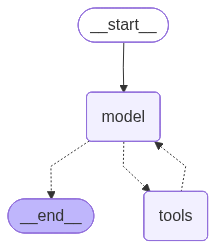

In [8]:
from langchain.agents import create_agent

agent = create_agent(llm_openai, toolkit.get_tools())

agent

Above we created an Agent. and tools have all the sql tools

Now we can literally invoke this agent and we will get the answer.

In [9]:
agent.invoke("How many customers do we have total?")

InvalidUpdateError: Expected dict, got How many customers do we have total?
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE

Here we got the error. This is the downside when we use the automated created functions. 

In [10]:
example_query = "How many customers do we have total?"

events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode = "values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

How many customers do we have total?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_oziXDCeJRwa2hI6yMg5PZpa8)
 Call ID: call_oziXDCeJRwa2hI6yMg5PZpa8
  Args:
    tool_input:
================================= Tool Message =================================
Name: sql_db_list_tables

orders
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_hGjmPPtVFMNJLf4jYbqUJ9As)
 Call ID: call_hGjmPPtVFMNJLf4jYbqUJ9As
  Args:
    table_names: orders
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE orders (
	order_id INTEGER, 
	customer_name TEXT, 
	product_name TEXT, 
	quantity INTEGER, 
	price REAL, 
	PRIMARY KEY (order_id)
)

/*
3 rows from orders table:
order_id	customer_name	product_name	quantity	price
1	Alice	Laptop	

You just create an Agent which can do anything in your database.

In [12]:
example_query = """Find the top 3 customers based on total revenue.
"Also show the total number of orders, total quantity purchased, 
"and their most frequently purchased product."""

events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode = "values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Find the top 3 customers based on total revenue.
"Also show the total number of orders, total quantity purchased, 
"and their most frequently purchased product.
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_ytP3LlMiocPEjlah9cTiFa9r)
 Call ID: call_ytP3LlMiocPEjlah9cTiFa9r
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

orders
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_SKUVg6U1UjV3U8zjN4dDvVNO)
 Call ID: call_SKUVg6U1UjV3U8zjN4dDvVNO
  Args:
    table_names: orders
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE orders (
	order_id INTEGER, 
	customer_name TEXT, 
	product_name TEXT, 
	quantity INTEGER, 
	price REAL, 
	PRIMARY KEY (

In [13]:
example_query = """Find the top 3 customers based on total revenue.
Also show total orders, total quantity, and most frequent product."""

events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode = "values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Find the top 3 customers based on total revenue.
Also show total orders, total quantity, and most frequent product.
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_c2zHN8uEWFBAZTocsNaGfwD7)
 Call ID: call_c2zHN8uEWFBAZTocsNaGfwD7
  Args:
    tool_input:
================================= Tool Message =================================
Name: sql_db_list_tables

orders
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_BHmekmQvlXgwxw3ZCd6tDSla)
 Call ID: call_BHmekmQvlXgwxw3ZCd6tDSla
  Args:
    table_names: orders
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE orders (
	order_id INTEGER, 
	customer_name TEXT, 
	product_name TEXT, 
	quantity INTEGER, 
	price REAL, 
	PRIMARY KEY (order_id)
)

/*
3 rows from o

# **Extra**

In [17]:
def chat():
    while True:
        q = input("You: ")
        if q.lower() in ["exit", "quit"]:
            break
        
        response = agent.invoke({
            "messages": [("user", q)]
        })
        
        print("Agent:", response["messages"][-1].content)

In [18]:
chat()

Agent: The database contains one table named: orders

Would you like me to show the schema for orders or display some sample rows?
Agent: Thanks — could you tell me what you mean by "Yes"? Do you want me to continue with something we were discussing, run a query, start a new task, or answer a question?
Agent: Do you mean the column names for a specific table in the connected database? If so, which table name would you like the columns for?

If you don't know the table name I can first list all tables for you — shall I do that?
Agent: The orders table has these columns:
- order_id
- customer_name
- product_name
- quantity
- price
Agent: The highest price is 1200.0.

Customers who have orders at that price (orders returned): Alice, David, Eve, Bob.
- Total orders with that price: 5 (Alice appears twice).
Would you like the order IDs or full order rows for those entries?
